[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/23_churn_clv_retention.ipynb)

# 📓 Notebook 23 — Churn, Customer Lifetime Value & Retention Targeting

**The business case notebook.** In NB 17 you trained your first churn classifier and in NB 18 you learned to evaluate it honestly. This notebook closes the loop that actually matters to a business: **model → money → decision**. You'll compute what a customer is *worth*, derive the retention-offer threshold from euros instead of gut feeling, and simulate a retention campaign under a real budget.

> 🧠 **Mental model.** A churn probability is not a decision. *"Who do we call, with which offer, at what cost, for how much expected profit?"* is the decision. Everything in this notebook converts the first into the second.

## 🎯 Learning objectives

By the end you can:

1. Compute **customer lifetime value (CLV)** for a contractual (subscription) business and explain its assumptions.
2. Turn churn probabilities into an **expected-value targeting rule** with a break-even threshold derived from offer cost, save rate, and CLV.
3. Simulate a **budget-constrained retention campaign** and compare targeting strategies by realized profit.
4. Explain the **uplift caveat**: why high churn risk ≠ high persuadability, and what "sleeping dogs" are.
5. Spot **post-outcome leakage** — the classic way churn models look spectacular and then fail in production.

## ✅ Prerequisites

Notebooks 1–13 and 17–19 (especially NB 17 — the churn classifier, NB 18 — evaluation in cost units, NB 19 — pipelines & leakage). All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
pd.set_option("display.width", 110)
print("Setup OK")

Setup OK


## 1. The business: HelpDeskAI, a subscription support-bot platform

HelpDeskAI sells an AI support-bot subscription in three plans. Finance gives you two numbers per plan: the **monthly fee** and the **gross margin** (the share of the fee that is profit after serving costs). Marketing gives you one more: a retention offer (a discount + onboarding call) costs **€60 per customer** and historically *saves* about **30 %** of the churners it reaches.

Your job: decide **which customers get the offer**.

In [2]:
n = 4000
plans  = rng.choice(["Basic", "Pro", "Enterprise"], size=n, p=[0.55, 0.35, 0.10])
fee    = pd.Series(plans).map({"Basic": 29, "Pro": 99, "Enterprise": 399}).to_numpy(float)
margin_rate = 0.80                                   # 80 % gross margin on every plan

tenure   = rng.integers(1, 48, n)                    # months as a customer
seats    = np.where(plans == "Enterprise", rng.integers(10, 60, n),
            np.where(plans == "Pro", rng.integers(3, 15, n), rng.integers(1, 4, n)))
usage    = rng.gamma(shape=2.0, scale=14, size=n)    # bot-hours used last 30 days
tickets  = rng.poisson(lam=np.where(usage < 10, 3.0, 1.2))   # support tickets last 90 days
nps      = np.clip(rng.normal(7.5 - 0.55 * tickets, 1.8), 0, 10).round()

In [3]:
# Hidden truth: low usage, many tickets, low NPS and short tenure drive churn.
# Plan matters too: Basic customers churn more, Enterprise accounts are stickier
# (annual contracts, dedicated success managers) — so value and risk pull apart.
logit = (0.4 - 0.05 * usage - 0.35 * nps + 0.45 * tickets
         - 0.015 * tenure + np.where(plans == "Basic", 0.55, 0.0)
         + np.where(plans == "Enterprise", -0.6, 0.0))
p_true  = 1 / (1 + np.exp(-logit))
churned = rng.binomial(1, p_true)                    # churned within the next 90 days

In [4]:
df = pd.DataFrame({"plan": plans, "monthly_fee": fee, "tenure_months": tenure,
                   "seats": seats, "usage_hours_30d": usage.round(1),
                   "tickets_90d": tickets, "nps": nps, "churned": churned})
print(df.head())
print(f"\nOverall 90-day churn rate: {df['churned'].mean():.1%}")

    plan  monthly_fee  tenure_months  seats  usage_hours_30d  tickets_90d   nps  churned
0    Pro         99.0             31     14             28.7            1  10.0        0
1  Basic         29.0             34      3             16.8            0   9.0        0
2    Pro         99.0             13      3              9.7            0  10.0        0
3    Pro         99.0             17     13             21.7            0   8.0        0
4  Basic         29.0             45      2             62.8            2   4.0        0

Overall 90-day churn rate: 12.4%


## 2. What is a customer worth? CLV for subscriptions

For a **contractual** business the workhorse formula is beautifully simple. If a customer pays a margin of *m* per month and has a monthly churn probability *c*, their expected remaining lifetime is a geometric series:

$$\text{CLV} = m \cdot \frac{1}{c} \quad\text{(expected months} = 1/c\text{)}$$

> 🎯 **Intuition.** If 4 % of a plan's customers leave each month, the *average* customer sticks around 1/0.04 = 25 more months. Value = monthly margin × 25.

> ⚠️ **Pitfall.** This assumes a *constant* churn rate (it isn't — loyal customers churn less), no discounting of future euros, and a contractual setting (subscriptions, not e-commerce). It's the right **first** model, not the last. We also cap lifetime at 48 months — finance never believes infinite sums.

In [5]:
monthly_churn = df.groupby("plan")["churned"].mean() / 3        # 90-day rate -> rough monthly rate
clv_table = pd.DataFrame({
    "monthly_margin_eur": df.groupby("plan")["monthly_fee"].first() * margin_rate,
    "monthly_churn": monthly_churn.round(4),
})
clv_table["exp_lifetime_months"] = (1 / clv_table["monthly_churn"]).clip(upper=48).round(1)
clv_table["CLV_eur"] = (clv_table["monthly_margin_eur"] * clv_table["exp_lifetime_months"]).round(0)
print(clv_table.sort_values("CLV_eur"))

# Attach a per-customer CLV (per-plan estimate)
df["clv"] = df["plan"].map(clv_table["CLV_eur"])

            monthly_margin_eur  monthly_churn  exp_lifetime_months  CLV_eur
plan                                                                       
Basic                     23.2         0.0479                 20.9    485.0
Pro                       79.2         0.0366                 27.3   2162.0
Enterprise               319.2         0.0228                 43.9  14013.0


📊 **See the gap.** The same numbers as a chart — Basic barely registers next to Enterprise. That is the whole point: an *identical* churn probability does **not** deserve identical attention.

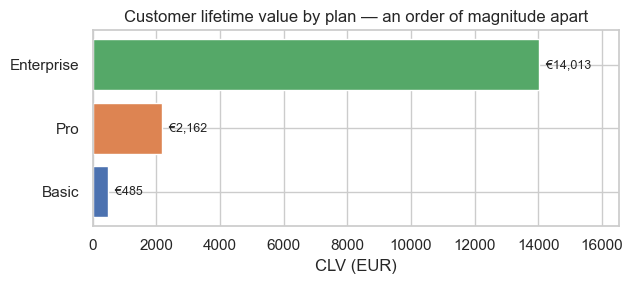

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3))
order_plans = clv_table.sort_values("CLV_eur")
ax.barh(order_plans.index, order_plans["CLV_eur"],
        color=["#4c72b0", "#dd8452", "#55a868"])
for y, v in enumerate(order_plans["CLV_eur"]):
    ax.text(v, y, f"  €{v:,.0f}", va="center", fontsize=9)
ax.margins(x=0.18)
ax.set_xlabel("CLV (EUR)")
ax.set_title("Customer lifetime value by plan — an order of magnitude apart")
plt.tight_layout(); plt.show()

---

### ✋ Quick exercise (~2 min) — CLV for a new plan

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

HelpDeskAI is launching a **"Team"** plan at €150/month with the same 80% gross margin. Suppose its monthly churn rate is 0.05. Using the **same capped formula** from this section (expected lifetime = `1/c`, capped at 48 months), compute the plan's CLV.

```python
fee_team   = 150
churn_team = 0.05
```

In [7]:
# ✍️ Your turn 👇
fee_team   = 150
churn_team = 0.05
# Compute the monthly margin, the capped expected lifetime, and the CLV:


<details>
<summary>✅ <b>Solution</b></summary>

```python
fee_team    = 150
churn_team  = 0.05
margin_team = fee_team * margin_rate          # 80% gross margin
lifetime    = min(1 / churn_team, 48)         # expected months, capped at 48
clv_team    = margin_team * lifetime
print(f"Team plan CLV: {clv_team:,.0f} EUR  (lifetime {lifetime:.0f} months)")
```

`1/0.05 = 20` months (below the 48 cap), so CLV = `120 × 20 = €2,400` — between Pro and Enterprise, exactly as a €150 plan should sit.
</details>

💡 **Read the table like a manager.** An Enterprise customer is worth an order of magnitude more than a Basic one — so an *identical* churn probability does **not** deserve identical attention. This single column changes everything downstream.

## 3. The churn model — NB 17's classifier, production-shaped

Same task as NB 17, but wrapped in the NB 19 pipeline discipline (categorical encoding inside the pipeline, no leakage) and evaluated with a probability metric, because we need calibrated-ish **probabilities**, not labels.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

FEATURES = ["plan", "tenure_months", "seats", "usage_hours_30d", "tickets_90d", "nps"]
X = df[FEATURES]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=42)
prep = ColumnTransformer([
    ("plan", OneHotEncoder(handle_unknown="ignore"), ["plan"]),
], remainder="passthrough")

model = Pipeline([("prep", prep),
                  ("clf", HistGradientBoostingClassifier(max_iter=200, random_state=42))])
model.fit(X_train, y_train)

p_churn = model.predict_proba(X_test)[:, 1]
print(f"Test AUC: {roc_auc_score(y_test, p_churn):.3f}")

Test AUC: 0.803


---

### ✋ Quick exercise (~2 min) — How aggressive is the naive 0.5 rule?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Using the model's predicted probabilities `p_churn` on the test set, what **fraction** of customers does the naive "0.5 cutoff" flag as churners? Compare that fraction to the **actual** churn rate in `y_test`. Does the rule over- or under-flag?

In [9]:
# ✍️ Your turn 👇
# Use p_churn (test-set probabilities) and y_test (actual outcomes):


<details>
<summary>✅ <b>Solution</b></summary>

```python
flagged = (p_churn > 0.5).mean()
actual  = y_test.mean()
print(f"Flagged by 0.5 cutoff: {flagged:.1%}")
print(f"Actual churn rate:     {actual:.1%}")
```

The 0.5 cutoff flags only ~7% of customers, well **below** the true ~12% churn rate — the naive rule is too conservative and silently abandons many real churners. That gap is exactly why the next section ditches 0.5 for a cost-based threshold.
</details>

## 4. From probability to decision — the expected-value rule

Targeting customer *i* with the offer has an expected profit of:

$$EV_i = p_i \cdot s \cdot \text{CLV}_i - C_{\text{offer}}$$

where $p_i$ is the churn probability, $s$ the save rate (0.30) and $C_{\text{offer}}$ = €60. Target exactly the customers with $EV_i > 0$, i.e. those above the **break-even probability**

$$p_i^* = \frac{C_{\text{offer}}}{s \cdot \text{CLV}_i}$$

> 🎯 **Intuition.** The threshold is *per customer*: for an Enterprise account (huge CLV) even a 4 % churn risk is worth a call; for a Basic account the offer only pays off at a much higher risk. A global 0.5 cutoff — the silent default of `.predict()` — is the wrong answer for **every** customer.

> 🚫 **Misconception — "Rank customers by churn probability and target from the top down."**
> Churn probability is only *half* the equation. The expected value of a save is `p × save_rate × CLV − cost`, so a low-risk Enterprise account can be worth far more than a near-certain Basic churner. Rank by **expected value**, not by `p` — the order can flip completely.

### 🔬 What actually happens: a probability is not a decision

Before we unleash a trained model on it, let's slow the EV rule right down. The single
idea that trips up newcomers is this:

> **A churn classifier does not output "will churn" / "won't churn". It outputs a
> _probability_ — a number between 0.0 and 1.0. _You_ turn that number into an action by
> choosing a threshold.**

`model.predict_proba(X)` hands you back a column of probabilities like
`[0.08, 0.91, 0.44, 0.62, …]`. To *do* something — send a retention offer or not — you
need a rule that maps each number to **act** or **ignore**. The simplest such rule is a
**threshold** *t*:

```text
        act if  p_churn ≥ t        ignore if  p_churn < t
```

Picture every customer as a dot on a 0→1 probability line, with a movable threshold *t*
splitting the line into two zones:

```text
   p(churn):  0.0 ──────────────────────── t=0.5 ──────────────────────── 1.0
              │                              ┊                              │
   customers: •A(.08)   •C(.31)   •E(.49)    ┊    •D(.62)   •B(.78)   •F(.93)
              │                              ┊                              │
              └────────── IGNORE ────────────┤├──────────── ACT ───────────┘
                       (p < t)               ┊            (p ≥ t)
                                       move me ←→ me
```

Slide *t* **left** → the ACT zone grows → you offer to *more* people (catch more real
churners, but waste offers on the loyal). Slide *t* **right** → the ACT zone shrinks → you
offer to *fewer* people (waste less, but miss real churners). The threshold is a **dial**,
and where you set it is a *business* choice — not a property of the model.


### The two ways a threshold can be wrong — and what each costs

Every threshold makes two kinds of mistake. Which one hurts more depends entirely on
**money**, and that is why 0.5 is almost never the right answer.

| The model says… | …and the truth is | Name | What it costs you |
|---|---|---|---|
| act (p ≥ t) | customer would **not** have churned | **False Positive** | one wasted offer ≈ `OFFER_COST` |
| act (p ≥ t) | customer **was** about to churn | **True Positive** | (a win) you may *save* their CLV |
| ignore (p < t) | customer **was** about to churn | **False Negative** | you lose them — a whole **CLV** walks out |
| ignore (p < t) | customer would not have churned | True Negative | (fine) nothing spent, nobody lost |

The asymmetry is the whole game:

* A **false positive** costs one offer — a few euros (`OFFER_COST`).
* A **false negative** costs an entire **CLV** — potentially thousands.

Because a missed churner is far more expensive than a wasted offer, you should be *eager*
to act → push the threshold **below** 0.5. How far below depends on the numbers, which is
exactly what `CLV = margin × expected_lifetime` lets us compute. A customer paying €40/month
at 70 % margin who stays ~30 months is worth `0.70 × 40 × 30 ≈ €840` — losing them dwarfs a
€60 offer, so even a modest churn risk is worth chasing.

> 🎯 **Mental model.** The classifier gives you a **probability**. The threshold is a
> **business lever set by costs**, not a fixed 0.5. "Move the threshold" literally means
> "change how cautious vs. aggressive my retention team is."


### 🧪 Proof: sweep the threshold on six customers and watch the profit move

No training, no sklearn — just six customers whose churn probabilities we *pretend* a model
already produced, each with a CLV. We sweep three thresholds (0.3 / 0.5 / 0.7) and, for
each, compute **who we target**, the **offer cost**, and the **expected value saved**. The
business-optimal threshold will *not* be 0.5.

Same EV arithmetic as Section 4, made fully concrete: targeting customer *i* earns an
expected `p_i × SAVE_RATE × CLV_i` (probability the offer lands × value rescued) and costs a
flat `OFFER_COST`. Net expected value of a threshold = (saved value) − (total offer spend),
summed over everyone we choose to act on.


In [10]:
import numpy as np
import pandas as pd

# Six customers. p_churn = probability a model ALREADY predicted (no training here).
# CLV = margin × expected lifetime value, in euros. Self-contained + reproducible.
customers = pd.DataFrame({
    "name":    ["Ana", "Ben", "Cleo", "Dan", "Eve", "Finn"],
    "p_churn": [0.08,  0.78,  0.31,   0.62,  0.49,  0.93],
    "clv":     [3200,   290,  2100,    840,  1500,   410],   # euros
})

SAVE_RATE  = 0.30     # an offer rescues an about-to-churn customer 30% of the time
OFFER_COST = 60.0     # euros per retention offer

In [11]:
def sweep(t):
    """Apply threshold t: act on everyone with p_churn >= t, return the economics."""
    act = customers["p_churn"] >= t
    targeted   = customers[act]
    offer_cost = OFFER_COST * len(targeted)
    # expected value rescued from those we act on:  p × save_rate × CLV
    ev_saved   = (targeted["p_churn"] * SAVE_RATE * targeted["clv"]).sum()
    net_ev     = ev_saved - offer_cost
    return len(targeted), offer_cost, ev_saved, net_ev, list(targeted["name"])

In [12]:
print(f"{'threshold':>9} | {'#target':>7} | {'offer €':>8} | {'EV saved €':>11} | {'NET EV €':>9} | targeted")
print("-" * 78)
rows = []
for t in [0.3, 0.5, 0.7]:
    n, cost, saved, net, who = sweep(t)
    rows.append((t, net))
    print(f"{t:>9.1f} | {n:>7} | {cost:>8.0f} | {saved:>11.0f} | {net:>9.0f} | {', '.join(who)}")

best_t = max(rows, key=lambda r: r[1])[0]
print("-" * 78)
print(f"Business-optimal of the three: t = {best_t}  (highest NET expected value)")
print(f"The naive default t = 0.5 is {'NOT ' if best_t != 0.5 else ''}the best choice here.")

threshold | #target |  offer € |  EV saved € |  NET EV € | targeted
------------------------------------------------------------------------------
      0.3 |       5 |      300 |         754 |       454 | Ben, Cleo, Dan, Eve, Finn
      0.5 |       3 |      180 |         338 |       158 | Ben, Dan, Finn
      0.7 |       2 |      120 |         182 |        62 | Ben, Finn
------------------------------------------------------------------------------
Business-optimal of the three: t = 0.3  (highest NET expected value)
The naive default t = 0.5 is NOT the best choice here.


### Reading the sweep — why the winner isn't 0.5

Walk down the `NET EV €` column:

* **t = 0.7** is *too cautious*. It only acts on the obvious cases (Ben, Finn) and **ignores
  Dan (p=0.62, CLV €840)** — a false negative that lets real expected value walk out the door.
* **t = 0.5** still misses Eve (p=0.49) — who sits *just* below the line — even though acting
  on her has positive expected value.
* **t = 0.3** scoops in Cleo and Eve too. Each extra offer costs €60 but rescues far more in
  expected CLV, so the net expected value *rises*. The optimum sits **below** the naive 0.5.

The lesson is not "0.3 is the magic number" — change the costs and the winner moves. The
lesson is that **the threshold is a knob you tune against `OFFER_COST` and `CLV`, not a
constant handed down by the model.** Cheap offers + valuable customers → push the threshold
*down* (act on faint risk). Expensive offers + low-value customers → push it *up*.

> 🧠 **Tie-back to Section 4.** A single global threshold is already better than blindly
> using 0.5 — but the *real* optimum sets a **different break-even threshold per customer**,
> `p* = OFFER_COST / (SAVE_RATE × CLV)`, because Ana's huge CLV justifies acting on far
> fainter risk than Finn's. That per-customer rule is exactly what the next cell computes on
> the trained model. The flat sweep above is the same idea with the dial held in one place.

> ⚠️ **Don't forget uplift.** `p_churn` measures *risk*, not how much your offer *changes*
> behaviour. The EV rule assumes acting helps; some customers leave regardless, and a few
> leave *because* you contacted them. The honest fix is an uplift model (flagged again right
> after Section 4). Until then, the cost-aware threshold is the defensible default.


### 🔮 Predict the output

Two customers, same retention offer (save rate `s = 0.30`, cost `€60`). We rank them two ways: by raw **churn probability**, and by **expected value** `p × s × CLV − 60`. Does the priority order stay the same?

```python
cust = [
    {"name": "Basic-Bob",  "p": 0.80, "clv":   400},   # very likely to churn, low value
    {"name": "Ent-Eve",    "p": 0.20, "clv": 5000},   # unlikely to churn, high value
]
s, cost = 0.30, 60
by_p  = sorted(cust, key=lambda c: -c["p"])
by_ev = sorted(cust, key=lambda c: -(c["p"]*s*c["clv"] - cost))
print("by prob:", [c["name"] for c in by_p])
print("by EV:  ", [c["name"] for c in by_ev])
```

Do the two lists print in the **same** order, or does the EV ranking put a *different* customer first?

In [13]:
# Predict first, then run.
cust = [
    {"name": "Basic-Bob",  "p": 0.80, "clv":   400},   # very likely to churn, low value
    {"name": "Ent-Eve",    "p": 0.20, "clv": 5000},   # unlikely to churn, high value
]
s, cost = 0.30, 60
by_p  = sorted(cust, key=lambda c: -c["p"])
by_ev = sorted(cust, key=lambda c: -(c["p"]*s*c["clv"] - cost))
for c in cust:
    print(f'{c["name"]:11s}  p={c["p"]:.2f}  CLV={c["clv"]:>5}  EV={c["p"]*s*c["clv"]-cost:+.0f}')
print("by prob:", [c["name"] for c in by_p])
print("by EV:  ", [c["name"] for c in by_ev])

Basic-Bob    p=0.80  CLV=  400  EV=+36
Ent-Eve      p=0.20  CLV= 5000  EV=+240
by prob: ['Basic-Bob', 'Ent-Eve']
by EV:   ['Ent-Eve', 'Basic-Bob']


<details>
<summary>💡 <b>Answer</b></summary>

**The order flips.** By probability, Basic-Bob (p=0.80) ranks first. But his EV is `0.80 × 0.30 × 400 − 60 = +€36`, while Ent-Eve's is `0.20 × 0.30 × 5000 − 60 = +€240` — nearly 7× more. With a limited budget you call **Ent-Eve first**. Ranking by raw churn probability quietly optimizes the wrong objective; ranking by expected value targets the money.
</details>

In [14]:
SAVE_RATE  = 0.30
OFFER_COST = 60.0

test = X_test.copy()
test["p_churn"]   = p_churn
test["churned"]   = y_test.to_numpy()
test["clv"]       = test["plan"].map(clv_table["CLV_eur"])
test["p_star"]    = OFFER_COST / (SAVE_RATE * test["clv"])      # per-customer break-even
test["ev_offer"]  = test["p_churn"] * SAVE_RATE * test["clv"] - OFFER_COST

print(test.groupby("plan")[["p_star"]].first().round(3))
print(f"\nCustomers with EV > 0:           {(test['ev_offer'] > 0).sum():>4}")
print(f"Customers with p_churn > 0.5:    {(test['p_churn'] > 0.5).sum():>4}   <- the naive rule")
print("Total expected profit (EV rule):", format(test.loc[test["ev_offer"] > 0, "ev_offer"].sum(), ",.0f"), "EUR")


            p_star
plan              
Basic        0.412
Enterprise   0.014
Pro          0.093

Customers with EV > 0:            161
Customers with p_churn > 0.5:      81   <- the naive rule
Total expected profit (EV rule): 47,021 EUR


📈 **The decision, drawn.** Each dot is a test customer; the dashed curve is the *exact* break-even where `p · s · CLV = cost`. Look top-left — low-risk **high-CLV** accounts we still **target** — and bottom-right — high-risk **low-CLV** customers we **skip**. Risk and value pull apart, so the flat 0.5 line (dotted) is the wrong cut for every plan.

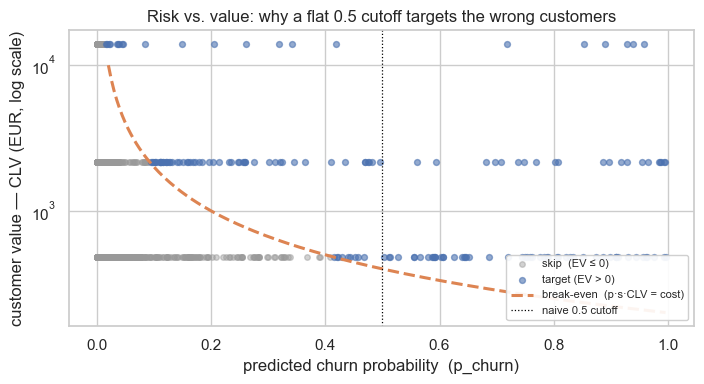

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 4))
target = test["ev_offer"] > 0
ax.scatter(test.loc[~target, "p_churn"], test.loc[~target, "clv"],
           s=16, alpha=0.45, color="#999999", label="skip  (EV ≤ 0)")
ax.scatter(test.loc[target, "p_churn"], test.loc[target, "clv"],
           s=18, alpha=0.60, color="#4c72b0", label="target (EV > 0)")
pp = np.linspace(0.02, float(test["p_churn"].max()), 200)
ax.plot(pp, OFFER_COST / (SAVE_RATE * pp), color="#dd8452", lw=2.2, ls="--",
        label="break-even  (p·s·CLV = cost)")
ax.axvline(0.5, color="black", lw=0.9, ls=":", label="naive 0.5 cutoff")
ax.set_yscale("log")
ax.set_xlabel("predicted churn probability  (p_churn)")
ax.set_ylabel("customer value — CLV (EUR, log scale)")
ax.set_title("Risk vs. value: why a flat 0.5 cutoff targets the wrong customers")
ax.legend(loc="lower right", framealpha=0.92, fontsize=8)
plt.tight_layout(); plt.show()

---

### ✋ Quick exercise (~2 min) — Is this Enterprise account worth a call?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

An Enterprise customer has CLV €14,013 but a churn probability of only **0.05**. Using the rule from this section, compute (a) the offer's expected value `EV = p · s · CLV − cost` and (b) the break-even probability `p* = cost / (s · CLV)`, with `s = SAVE_RATE` and `cost = OFFER_COST`. Should you target them?

```python
clv_ent = 14013
p       = 0.05
```

In [16]:
# ✍️ Your turn 👇
clv_ent = 14013
p       = 0.05
# Compute ev (offer expected value) and p_star (break-even), then decide:


<details>
<summary>✅ <b>Solution</b></summary>

```python
clv_ent = 14013
p       = 0.05
ev      = p * SAVE_RATE * clv_ent - OFFER_COST
p_star  = OFFER_COST / (SAVE_RATE * clv_ent)
print(f"EV of offer:        {ev:,.0f} EUR")
print(f"Break-even p*:      {p_star:.3f}")
print("Target?", "YES" if ev > 0 else "NO")
```

EV ≈ `+€150` and `p* ≈ 0.014`. Because the actual risk (0.05) sits **well above** the tiny break-even, the offer pays off — a high-CLV account justifies acting on even faint churn risk, the opposite of what a flat 0.5 cutoff would do.
</details>

> ⚠️ **The uplift caveat (read twice).** $p_i$ measures *risk*, not *persuadability*. Some high-risk customers would leave no matter what (lost causes); some would have stayed anyway (sure things); and a few leave **because** you called them — the famous *sleeping dogs*. The honest fix is an **uplift model** trained on a randomized campaign (treatment vs control), which estimates $\Delta p_i$ = how much the offer *changes* behaviour. Stretch B builds the simplest version. Until you have experiment data, the EV rule above is the defensible default — just don't oversell it.

## 5. The campaign — €18,000 budget, three targeting strategies

Budget buys **300 offers**. We compare: (a) rank by expected value, (b) rank by raw churn probability, (c) random outreach — and simulate realized profit on the test set using the *actual* outcomes. A single simulated campaign is mostly luck (which churners happened to accept the offer), so we average **200 simulated runs** per strategy.

In [17]:
BUDGET_N = 300
N_SIMS   = 200            # one simulated campaign is mostly luck — average many

def campaign_profit(ranked_idx, roll, n=BUDGET_N):
    chosen = test.loc[ranked_idx[:n]]
    # an offer 'saves' a churner with prob SAVE_RATE; non-churners cost the offer for nothing
    saved = (chosen["churned"] == 1) & (roll.loc[chosen.index] < SAVE_RATE)
    return float((saved * chosen["clv"]).sum() - OFFER_COST * n)

strategies = {
    "EV ranking":        test.sort_values("ev_offer", ascending=False).index,
    "p(churn) ranking":  test.sort_values("p_churn", ascending=False).index,
    "random":            test.sample(frac=1, random_state=7).index,
}

In [18]:
sim_rng = np.random.default_rng(7)
profits = {name: [] for name in strategies}
for _ in range(N_SIMS):
    roll = pd.Series(sim_rng.random(len(test)), index=test.index)   # fresh luck, same customers
    for name, idx in strategies.items():
        profits[name].append(campaign_profit(idx, roll))
results = pd.Series({name: np.mean(v) for name, v in profits.items()})
print(results.round(0).to_string())

EV ranking          35052.0
p(churn) ranking    28034.0
random              -2660.0


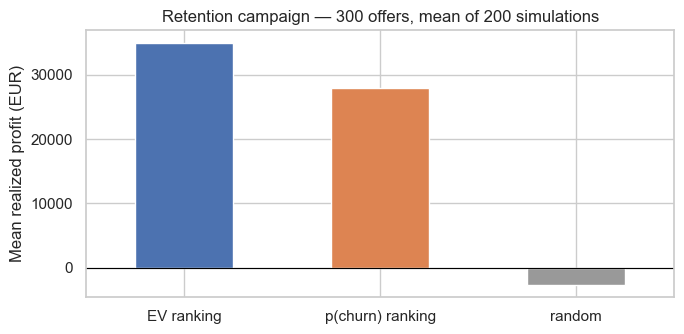

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.5))
results.plot.bar(ax=ax, color=["#4c72b0", "#dd8452", "#999999"])
ax.set_ylabel("Mean realized profit (EUR)")
ax.set_title(f"Retention campaign — {BUDGET_N} offers, mean of {N_SIMS} simulations")
ax.axhline(0, color="black", lw=0.8); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

---

### ✋ Quick exercise (~2 min) — Quantify the ranking lift

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

From the `results` Series just computed, how many **euros more** does the `"EV ranking"` strategy earn on average than `"p(churn) ranking"`? Express that gap as a **percentage lift** over the probability ranking.

In [20]:
# ✍️ Your turn 👇
# Use the `results` Series printed above (one mean profit per strategy):


<details>
<summary>✅ <b>Solution</b></summary>

```python
gap  = results["EV ranking"] - results["p(churn) ranking"]
lift = gap / results["p(churn) ranking"]
print(f"EV ranking earns {gap:,.0f} EUR more on average ({lift:.1%} lift)")
```

The EV ranking wins by several thousand euros — a double-digit % lift — **without retraining the model**. Only the column we sorted by changed: spending the same 300 offers on high-CLV accounts instead of high-risk-but-cheap ones.
</details>

💡 **Why EV beats raw probability.** Across 200 simulated campaigns the EV ranking averages ≈ €35k profit vs ≈ €28k for the probability ranking — a ~25 % lift from changing *nothing but the ranking column*. The probability ranking burns offers on high-risk *Basic* customers worth ≈ €485; the EV ranking spends them on lower-risk *Pro/Enterprise* accounts worth thousands, where even a faint chance of a save pays for the call. Random outreach loses money outright. Same model, different ranking column, very different money.

## 6. How many offers *should* we send? The profit curve

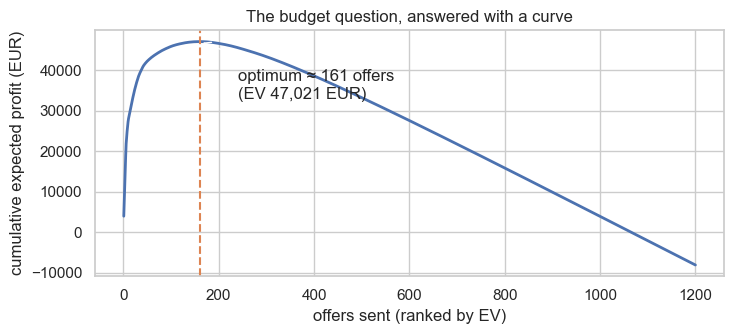

Marginal customer #161 has EV ≈ 0 — beyond that, every offer destroys value.


In [21]:
order = test.sort_values("ev_offer", ascending=False)
cum_ev = (order["p_churn"] * SAVE_RATE * order["clv"] - OFFER_COST).cumsum()

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.plot(range(1, len(cum_ev) + 1), cum_ev.values, lw=2)
best_k = int(np.argmax(cum_ev.values)) + 1
ax.axvline(best_k, ls="--", color="#dd8452")
ax.annotate(f"optimum ≈ {best_k} offers\n(EV {cum_ev.values[best_k-1]:,.0f} EUR)",
            xy=(best_k, cum_ev.values[best_k-1]), xytext=(best_k + 80, cum_ev.values[best_k-1] * 0.7),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("offers sent (ranked by EV)"); ax.set_ylabel("cumulative expected profit (EUR)")
ax.set_title("The budget question, answered with a curve"); plt.tight_layout(); plt.show()
print(f"Marginal customer #{best_k} has EV ≈ 0 — beyond that, every offer destroys value.")

> 🎛️ **Try it live.** The cell below is interactive in Jupyter/Colab — drag the sliders to feel the trade-off. (It also runs fine without `ipywidgets`; you just get the default values as a static chart.)

In [22]:
# Interactive — needs ipywidgets (preinstalled on Colab; `pip install ipywidgets` locally)
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

def show_campaign(save_rate=0.30, offer_cost=60.0):
    ev = test["p_churn"] * save_rate * test["clv"] - offer_cost
    cum = np.sort(ev.values)[::-1].cumsum()
    best_k = int(np.argmax(cum)) + 1 if cum.max() > 0 else 0
    best_profit = float(cum.max()) if cum.max() > 0 else 0.0
    fig, ax = plt.subplots(figsize=(7.5, 3.3))
    ax.plot(range(1, len(cum) + 1), cum, lw=2)
    if best_k:
        ax.axvline(best_k, ls="--", color="#dd8452")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("offers sent (ranked by EV)"); ax.set_ylabel("cumulative expected profit (EUR)")
    ax.set_title(f"save rate {save_rate:.0%}, offer EUR {offer_cost:.0f}  ->  "
                 f"send {best_k} offers, profit EUR {best_profit:,.0f}")
    plt.tight_layout(); plt.show()

if _HAS_WIDGETS:
    interact(show_campaign,
             save_rate=FloatSlider(value=0.30, min=0.05, max=0.60, step=0.05, description="save rate"),
             offer_cost=FloatSlider(value=60.0, min=10, max=200, step=10, description="offer EUR"))
else:
    show_campaign()

interactive(children=(FloatSlider(value=0.3, description='save rate', max=0.6, min=0.05, step=0.05), FloatSlid…

## 7. What this notebook did *not* solve (honest section)

- **Persuadability.** We targeted *risk*. A randomized holdout in every campaign is how you graduate to uplift (Stretch B).
- **Time.** We used a random split. A production churn model must be validated on a **temporal split** — train on months 1–9, score month 10 — or you will overstate performance (same leakage family as NB 19 §6).
- **Constant churn CLV.** Survival models (lifelines, scikit-survival) refine the lifetime estimate.
- **Offer design.** We priced one offer. Real retention teams test offer *ladders* (cheap email → discount → call).

---


## 🧠 The story in one screen

Trace the whole arc back to the decision we set out to make for **HelpDeskAI** — *which customers get the €60 offer?*

1. **The data** told us who's at risk — but risk alone is the wrong target.
2. **CLV** told us who's *worth saving*: an Enterprise account is worth ~30× a Basic one, so identical churn risk does **not** deserve identical attention.
3. The **model** turned features into a *probability* — and the mental model held the whole way: **a probability is not a decision.**
4. The **expected-value rule** `EV = p · s · CLV − cost` converted that probability into euros, giving each customer their *own* break-even threshold `p* = cost / (s · CLV)` — never a flat 0.5.
5. The **campaign** proved it pays: same model, EV ranking instead of probability ranking, ~25 % more profit and a curve telling us *exactly how many* offers to send.

> 🧭 **Mental model, one last time.** The model hands you a number; *you* turn it into an action, and the exchange rate from number to action is **money**. That single move — risk → expected value → costed decision — is what makes this "the business case notebook," and it's the pattern you'll reuse in fraud (NB 24), where the costs get even more lopsided.


## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ CLV with discounting
The finance team objects: *"future euros are worth less than today's euros."* Write `clv_discounted(margin, monthly_churn, annual_rate=0.10, horizon=48)` that sums the discounted expected margin: in month $t$ the customer is still around with probability $(1-c)^t$ and €1 is worth $1/(1+r_m)^t$ with monthly rate $r_m = (1+r)^{1/12}-1$. Compare to the undiscounted CLV for the Pro plan.

In [23]:
# Starter — fill in the function body
def clv_discounted(margin, monthly_churn, annual_rate=0.10, horizon=48):
    ...  # your code here

pro_margin = float(clv_table.loc["Pro", "monthly_margin_eur"])
pro_churn  = float(clv_table.loc["Pro", "monthly_churn"])
# print(clv_discounted(pro_margin, pro_churn))

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def clv_discounted(margin, monthly_churn, annual_rate=0.10, horizon=48):
    r_m = (1 + annual_rate) ** (1 / 12) - 1
    months = np.arange(1, horizon + 1)
    survival = (1 - monthly_churn) ** months
    discount = 1 / (1 + r_m) ** months
    return float((margin * survival * discount).sum())

pro_margin = float(clv_table.loc["Pro", "monthly_margin_eur"])
pro_churn  = float(clv_table.loc["Pro", "monthly_churn"])
disc = clv_discounted(pro_margin, pro_churn)
undisc = float(clv_table.loc["Pro", "CLV_eur"])
print(f"Pro CLV undiscounted: {undisc:,.0f} EUR | discounted: {disc:,.0f} EUR")
assert disc < undisc
```

**Why this works:** survival × discount is exactly the expected present value of month *t*'s margin; summing a finite horizon replaces the closed-form geometric series and makes the cap explicit. Discounting always *lowers* CLV, so the assert documents the sanity check.
</details>

### Exercise 2 — ⭐⭐ Break-even threshold function
Write `breakeven_p(clv, save_rate=0.30, offer_cost=60.0)` and use it to answer: at what churn probability does the offer pay off for each plan? Then count how many *test-set* customers sit above their own plan's threshold but **below** the naive 0.5 cutoff — the customers the naive rule silently abandons.

In [24]:
# Starter
def breakeven_p(clv, save_rate=0.30, offer_cost=60.0):
    ...  # your code here

# thresholds = clv_table["CLV_eur"].apply(breakeven_p)
# print(thresholds)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def breakeven_p(clv, save_rate=0.30, offer_cost=60.0):
    return offer_cost / (save_rate * clv)

thresholds = clv_table["CLV_eur"].apply(breakeven_p)
print(thresholds.round(3))

missed = ((test["p_churn"] > test["p_star"]) & (test["p_churn"] <= 0.5)).sum()
print(f"Profitable-to-target customers the 0.5 rule abandons: {missed}")
```

**Why this works:** solving $p\,s\,\text{CLV} - C = 0$ for $p$ gives the threshold directly. The "missed" count is the concrete business cost of treating a probability cutoff as a constant — almost all of the abandoned customers are high-CLV plans whose break-even sits far below 0.5.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: The 0.99-AUC trap
A colleague "improves" the model by adding a new column and proudly reports AUC 0.99. The cell below runs without errors — **that's the problem.** Find the bug, explain *why* the number is a lie, and fix the evaluation.

In [25]:
# A colleague's 'improvement' — runs fine, reports a spectacular number. What's wrong?
df_leaky = df.copy()
# refunds are processed AFTER a customer cancels — at scoring time this is unknowable
df_leaky["refund_processed"] = (df_leaky["churned"] == 1) & (rng.random(len(df_leaky)) < 0.95)

Xl = pd.get_dummies(df_leaky[FEATURES + ["refund_processed"]], columns=["plan"])
yl = df_leaky["churned"]
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(Xl, yl, test_size=0.3, stratify=yl, random_state=42)
leaky_model = HistGradientBoostingClassifier(max_iter=100, random_state=42).fit(Xl_tr, yl_tr)
auc_leaky = roc_auc_score(yl_te, leaky_model.predict_proba(Xl_te)[:, 1])
print(f"AUC with the new feature: {auc_leaky:.3f}  <- suspiciously good. 🚩")


AUC with the new feature: 0.996  <- suspiciously good. 🚩


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# The bug: 'refund_processed' is POST-OUTCOME information. Refunds happen because the
# customer already cancelled — at the moment you'd actually score customers, the column
# doesn't exist yet. The model learned 'refund -> churn', which is the label in disguise.
Xc = pd.get_dummies(df[FEATURES], columns=["plan"])     # drop the leaky column
yc = df["churned"]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, stratify=yc, random_state=42)
clean_model = HistGradientBoostingClassifier(max_iter=100, random_state=42).fit(Xc_tr, yc_tr)
auc_clean = roc_auc_score(yc_te, clean_model.predict_proba(Xc_te)[:, 1])
print(f"Honest AUC without it: {auc_clean:.3f}")
```

**Why this works:** the test is *"would this value exist in the database at scoring time?"* For refunds, the answer is no. NB 19 §6 called this **target leakage**; churn is where it bites hardest in practice because so many CRM columns (cancellation reason, exit-survey score, final invoice) are written *after* the event you predict. The honest AUC is lower — and real.
</details>

### Exercise 4 — ⭐⭐ `profit_at_budget`
Write `profit_at_budget(ranking_col, n)` that returns the *expected* campaign profit when targeting the top-`n` test customers ranked by the given column (use the EV formula, not the simulation). Compare `"ev_offer"` vs `"p_churn"` at n = 100, 300, 600.

In [26]:
# Starter
def profit_at_budget(ranking_col, n):
    ...  # your code here

# for n in (100, 300, 600):
#     print(n, profit_at_budget("ev_offer", n), profit_at_budget("p_churn", n))

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def profit_at_budget(ranking_col, n):
    top = test.sort_values(ranking_col, ascending=False).head(n)
    ev = top["p_churn"] * SAVE_RATE * top["clv"] - OFFER_COST
    return float(ev.sum())

for n in (100, 300, 600):
    a = profit_at_budget("ev_offer", n)
    b = profit_at_budget("p_churn", n)
    print(f"n={n:>3}  EV-ranked {a:>10,.0f} EUR   p-ranked {b:>10,.0f} EUR   gap {a-b:>9,.0f}")
```

**Why this works:** both strategies are scored with the *same* expected-profit formula; only the ranking differs. The gap is largest at small budgets (the EV ranking front-loads high-CLV accounts) and shrinks as the budget grows — by the time you can afford everyone, ranking no longer matters.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Does calibration change the money?
Wrap the classifier in `sklearn.calibration.CalibratedClassifierCV` (isotonic, `cv=3`) and recompute the EV ranking. Compare the top-300 overlap and `profit_at_budget` before/after. *When* does calibration matter for ranking-based decisions, and when doesn't it?

In [27]:
# Starter — sketch:
# from sklearn.calibration import CalibratedClassifierCV
# cal = CalibratedClassifierCV(model, method="isotonic", cv=3).fit(X_train, y_train)
# p_cal = cal.predict_proba(X_test)[:, 1]
# ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from sklearn.calibration import CalibratedClassifierCV

cal = CalibratedClassifierCV(model, method="isotonic", cv=3).fit(X_train, y_train)
p_cal = cal.predict_proba(X_test)[:, 1]

cmp = test.copy()
cmp["ev_cal"] = p_cal * SAVE_RATE * cmp["clv"] - OFFER_COST
top_raw = set(cmp.sort_values("ev_offer", ascending=False).head(300).index)
top_cal = set(cmp.sort_values("ev_cal", ascending=False).head(300).index)
print(f"Top-300 overlap: {len(top_raw & top_cal)} / 300")

ev_cal_sum = float(cmp.sort_values("ev_cal", ascending=False).head(300)["ev_cal"].sum())
print(f"Expected profit (calibrated ranking, top 300): {ev_cal_sum:,.0f} EUR")
```

**Why this works:** calibration is a *monotone-ish* correction, so a pure single-model ranking barely moves — but the EV rule is **not** pure ranking: the per-customer threshold $p^*$ compares probabilities to an absolute scale (euros). Miscalibrated probabilities get the *cutoff* wrong (you send too many or too few offers) even when the order is fine. Rule of thumb: ranking decisions tolerate miscalibration; threshold and budget-sizing decisions don't (NB 18 §7).
</details>

### Stretch exercise B — ⭐⭐⭐ A first uplift model (two-model approach)
Simulate last quarter's campaign: 50 % of customers received the offer (`treated=1`), and the offer *causally* reduced churn for persuadable customers. Train one model on treated customers and one on control, score everyone with both, and rank by **uplift** $\hat{p}_{control} - \hat{p}_{treated}$. Compare with the risk ranking: which customers move?

In [28]:
# Starter — generate a synthetic experiment inside your solution, then:
# uplift = p_control_hat - p_treated_hat

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
exp_rng = np.random.default_rng(11)
hist = df.copy()
hist["treated"] = exp_rng.binomial(1, 0.5, len(hist))
# persuadables: medium-risk customers respond to the offer; lost causes & sure things don't
persuadable = (p_true > 0.25) & (p_true < 0.6)
p_after = np.where(hist["treated"].to_numpy() == 1,
                   np.where(persuadable, p_true * 0.5, p_true), p_true)
hist["churned_exp"] = exp_rng.binomial(1, p_after)

Xh = pd.get_dummies(hist[FEATURES], columns=["plan"])
m_t = HistGradientBoostingClassifier(max_iter=120, random_state=0).fit(
        Xh[hist["treated"] == 1], hist.loc[hist["treated"] == 1, "churned_exp"])
m_c = HistGradientBoostingClassifier(max_iter=120, random_state=0).fit(
        Xh[hist["treated"] == 0], hist.loc[hist["treated"] == 0, "churned_exp"])

uplift = m_c.predict_proba(Xh)[:, 1] - m_t.predict_proba(Xh)[:, 1]
risk   = m_c.predict_proba(Xh)[:, 1]
top_uplift = set(np.argsort(-uplift)[:300]); top_risk = set(np.argsort(-risk)[:300])
print(f"Overlap of top-300 by uplift vs by risk: {len(top_uplift & top_risk)} / 300")
print(f"Mean true churn prob of uplift picks: {p_true[list(top_uplift)].mean():.2f} (medium, not extreme)")
```

**Why this works:** the two-model (T-learner) approach estimates the *treatment effect* as the difference between the control-world and treated-world predictions. The picks concentrate in the **medium-risk band** — exactly the persuadables we planted — while the risk ranking chases extreme-risk customers, many of whom are lost causes. The overlap number makes the difference tangible. Production uplift work adds honest validation (Qini curves) and a real randomized control group.
</details>

### Stretch exercise C — ⭐⭐ Design the retention A/B test
Before rolling out, the team wants proof the offer works. Using NB 10's sample-size formula (two proportions, α = 0.05, power = 0.80), how many churn-risk customers per arm do you need to detect a save-rate of 30 % vs 0 % control… and vs a realistic 25 % vs 30 %?

In [29]:
# Starter — recall from NB 10:
# n per arm ≈ ((z_alpha/2 + z_beta)^2 * (p1(1-p1) + p2(1-p2))) / (p1 - p2)^2

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from scipy import stats

def n_per_arm(p1, p2, alpha=0.05, power=0.80):
    za = stats.norm.ppf(1 - alpha / 2)
    zb = stats.norm.ppf(power)
    return int(np.ceil((za + zb) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2)) / (p1 - p2) ** 2))

# Run the experiment on the customers you would actually TARGET (EV > 0), not the
# whole base — their churn rate is several times higher, so the same relative
# effect is a much bigger absolute difference and far easier to detect.
at_risk = test[test["ev_offer"] > 0]
base = at_risk["churned"].mean()                # churn rate among targeted customers
print(f"Churn among targeted (EV > 0) customers: {base:.2f}")
print(f"Detect 30% save (churn {base:.2f} -> {base*0.7:.2f}): n/arm = {n_per_arm(base, base*0.7)}")
print(f"Detect 25% vs 30% save:                  n/arm = {n_per_arm(base*0.75, base*0.7)}")
```

**Why this works:** *where* you run the test matters as much as the formula. Among the targeted high-risk segment (churn ≈ 44 %) a 30 % save rate is a huge absolute effect, so a couple of hundred customers per arm suffice — cheap. Run the same test on the whole customer base (churn ≈ 12 %) and you'd need thousands per arm for the identical offer. And distinguishing a 25 % from a 30 % save rate needs *thousands* per arm even in the high-risk segment, because the detectable effect enters the formula **squared**. Practical consequence: prove existence first, on the segment you actually target; optimize offer variants later; and don't promise the CFO precision you can't afford.
</details>

### Stretch exercise D — ⭐⭐ Sensitivity: what if marketing oversold the save rate?
The 30 % save rate came from one old campaign. Recompute the optimal number of offers and the expected profit for save rates 10 %–50 %. At what save rate does the campaign stop being worth running at all?

In [30]:
# Starter
# for s in np.arange(0.10, 0.51, 0.05): ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rows = []
for s in np.arange(0.10, 0.51, 0.05):
    ev_s = test["p_churn"] * s * test["clv"] - OFFER_COST
    ev_sorted = np.sort(ev_s.values)[::-1].cumsum()
    k = int(np.argmax(ev_sorted)) + 1 if ev_sorted.max() > 0 else 0
    rows.append({"save_rate": round(float(s), 2), "optimal_offers": k,
                 "expected_profit": round(float(max(ev_sorted.max(), 0.0)), 0)})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))
worth_it = sens.loc[sens["expected_profit"] > 0, "save_rate"].min()
print(f"\nCampaign is profitable for save rates >= {worth_it}")
```

**Why this works:** the save rate scales the *benefit* side of every customer's EV linearly, so both the cutoff and the campaign size move with it. Presenting decisions as a sensitivity table ("profitable as long as s ≥ X") is far more credible to a CFO than a single point estimate — and it tells you what the A/B test from Stretch C actually has to establish.
</details>

## 🎁 Bonus mini-project — the retention playbook memo

Combine everything into a function `retention_memo()` that returns a markdown string for the leadership team: churn rate and CLV per plan, the recommended targeting rule (per-plan break-even thresholds), the optimal campaign size and expected profit, plus the two caveats every honest memo needs (risk ≠ persuadability; temporal validation pending). Print it. If you did NB 28, you know what to do next with a memo like this: hand the *numbers* to an LLM and let it draft the prose — never the other way round.

## ✅ Self-assessment checklist

- [ ] I can derive CLV for a subscription business and name its three biggest assumptions.
- [ ] I can convert a churn probability into an expected-value decision with a per-customer threshold.
- [ ] I can explain to a manager why EV ranking beats probability ranking with the same model.
- [ ] I can explain sleeping dogs and why uplift needs a randomized control group.
- [ ] I caught the post-outcome leakage column and can name two more CRM columns with the same disease.

## 🚀 Next step

Continue with **Notebook 24 — Fraud & Anomaly Detection** (`./24_fraud_anomaly_detection.ipynb`), where the positives get rarer (0.5 %), the costs get more asymmetric, and the adversary fights back.